In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv("employes.csv")

In [59]:
print(df.head())  
df.tail() 
df.info()      # types + nulls
df.dtypes      # types seulement
df.columns     # noms des colonnes
df.isnull().sum()

   num_emp    nom_emp       poste  superieur date_embauche  salaire  \
0     7369  Coquillet  Technicien     7902.0    1980-12-17      800   
1     7499     Parent  Commercial     7698.0    1981-02-20     1600   
2     7521      Henry  Commercial     7698.0    1981-02-22     1250   
3     7566   Dumoulin   Directeur     7839.0    1981-04-02     2975   
4     7654     Ferron  Commercial     7698.0    1981-09-28     1250   

   commission  num_dep  
0         NaN       20  
1       300.0       30  
2       500.0       30  
3         NaN       20  
4      1400.0       30  
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_emp        14 non-null     int64  
 1   nom_emp        14 non-null     str    
 2   poste          14 non-null     str    
 3   superieur      13 non-null     float64
 4   date_embauche  14 non-null     str    
 5   salaire        14 n

num_emp           0
nom_emp           0
poste             0
superieur         1
date_embauche     0
salaire           0
commission       10
num_dep           0
dtype: int64

In [60]:
df["commission"] = df["commission"].fillna(0)
df.isnull().sum()

num_emp          0
nom_emp          0
poste            0
superieur        1
date_embauche    0
salaire          0
commission       0
num_dep          0
dtype: int64

In [61]:
def categorize_commission(x):
    if x > 0:
        return "Oui"
    else:
        return "Non"
df["has_commission"] = df["commission"].apply(categorize_commission)
df.head()

,num_emp,nom_emp,poste,superieur,date_embauche,salaire,commission,num_dep,has_commission
0,7369,Coquillet,Technicien,7902.0,1980-12-17,800,0.0,20,Non
1,7499,Parent,Commercial,7698.0,1981-02-20,1600,300.0,30,Oui
2,7521,Henry,Commercial,7698.0,1981-02-22,1250,500.0,30,Oui
3,7566,Dumoulin,Directeur,7839.0,1981-04-02,2975,0.0,20,Non
4,7654,Ferron,Commercial,7698.0,1981-09-28,1250,1400.0,30,Oui


# Part 2

In [62]:
df["poste"].value_counts()

poste
Technicien    4
Commercial    4
Directeur     3
Analyste      2
Président     1
Name: count, dtype: int64

In [63]:
print(df["poste"].value_counts().idxmax())

Technicien


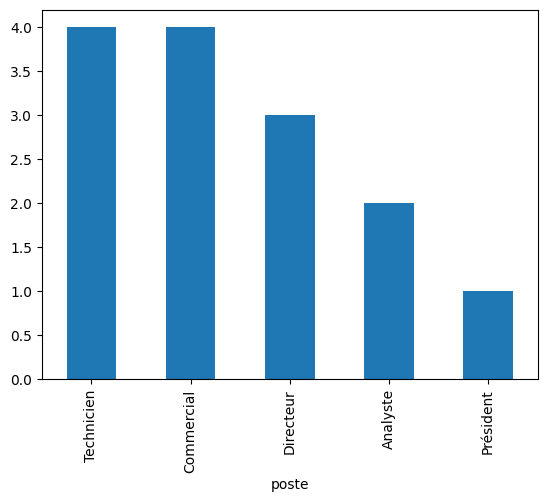

In [64]:
df["poste"].value_counts().plot(kind="bar")
plt.show()

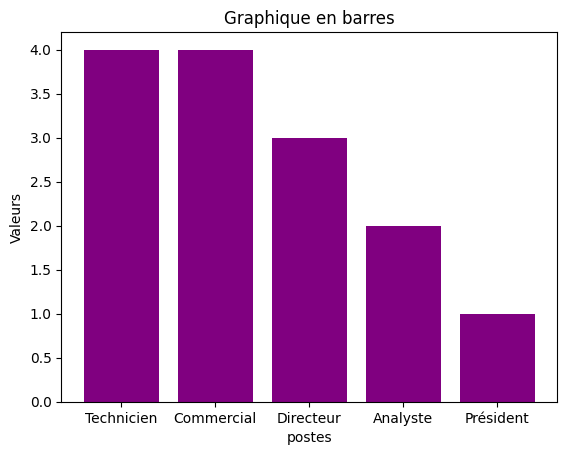

In [65]:
plt.bar(df["poste"].value_counts().index, df["poste"].value_counts().values, color='purple')
plt.title("Graphique en barres")
plt.xlabel("postes")
plt.ylabel("Valeurs")
plt.show()

In [66]:
df.groupby("poste")["salaire"].mean()

poste
Analyste      3000.000000
Commercial    1400.000000
Directeur     2758.333333
Président     5000.000000
Technicien    1037.500000
Name: salaire, dtype: float64

In [67]:
df.groupby("poste")["salaire"].mean().idxmax()

'Président'

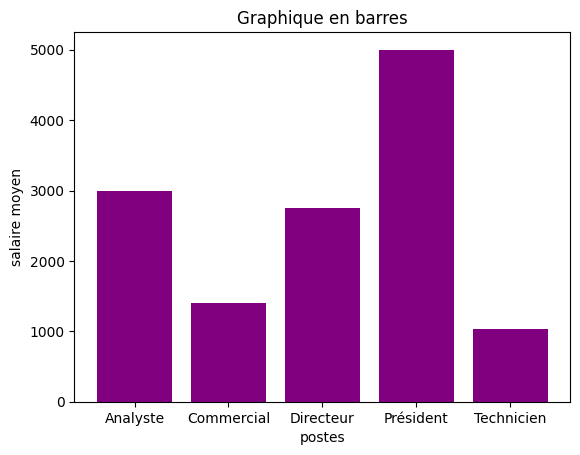

In [68]:
plt.bar(df.groupby("poste")["salaire"].mean().index, df.groupby("poste")["salaire"].mean().values, color='purple')
plt.title("Graphique en barres")
plt.xlabel("postes")
plt.ylabel("salaire moyen")
plt.show()

In [69]:
df.groupby("poste")["salaire"].sum()

poste
Analyste      6000
Commercial    5600
Directeur     8275
Président     5000
Technicien    4150
Name: salaire, dtype: int64

In [70]:
[df.groupby("poste")["salaire"].sum() > 2500]

[poste
 Analyste      True
 Commercial    True
 Directeur     True
 Président     True
 Technicien    True
 Name: salaire, dtype: bool]

# Part 3 

In [71]:
salaire_moyenne = df["salaire"].mean()
salaire_min = df["salaire"].min()
salaire_max = df["salaire"].max()
salaire_mediane = df["salaire"].median()
print(f"tous les salaires moyens: {salaire_moyenne}, min: {salaire_min}, max: {salaire_max}, mediane: {salaire_mediane}")

tous les salaires moyens: 2073.214285714286, min: 800, max: 5000, mediane: 1550.0


In [72]:
df[(df["salaire"] > 1500) & (df["salaire"] < 3000)]

,num_emp,nom_emp,poste,superieur,date_embauche,salaire,commission,num_dep,has_commission
1,7499,Parent,Commercial,7698.0,1981-02-20,1600,300.0,30,Oui
3,7566,Dumoulin,Directeur,7839.0,1981-04-02,2975,0.0,20,Non
5,7698,Capon,Directeur,7839.0,1981-05-01,2850,0.0,30,Non
6,7782,Martin,Directeur,7839.0,1981-06-09,2450,0.0,10,Non


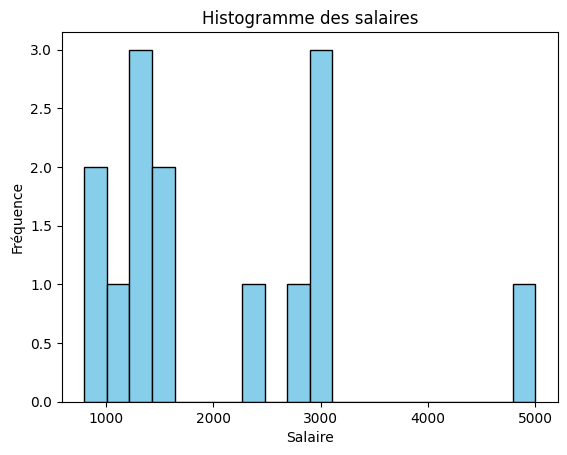

In [73]:
plt.hist(df["salaire"], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogramme des salaires")
plt.xlabel("Salaire")
plt.ylabel("Fréquence")
plt.show()

In [74]:
df["salaire-total"] = df["salaire"] + df["commission"]
df.head()

,num_emp,nom_emp,poste,superieur,date_embauche,salaire,commission,num_dep,has_commission,salaire-total
0,7369,Coquillet,Technicien,7902.0,1980-12-17,800,0.0,20,Non,800.0
1,7499,Parent,Commercial,7698.0,1981-02-20,1600,300.0,30,Oui,1900.0
2,7521,Henry,Commercial,7698.0,1981-02-22,1250,500.0,30,Oui,1750.0
3,7566,Dumoulin,Directeur,7839.0,1981-04-02,2975,0.0,20,Non,2975.0
4,7654,Ferron,Commercial,7698.0,1981-09-28,1250,1400.0,30,Oui,2650.0


In [77]:
#show the employe with the highest salary
df.loc[df["salaire"].idxmax()]

num_emp                 7839
nom_emp               Patton
poste              Président
superieur                NaN
date_embauche     1981-11-17
salaire                 5000
commission               0.0
num_dep                   10
has_commission           Non
salaire-total         5000.0
Name: 8, dtype: object

In [ ]:
df[["salaire", "salaire-total"]]

,salaire,salaire-total
0,800,800.0
1,1600,1900.0
2,1250,1750.0
3,2975,2975.0
4,1250,2650.0
5,2850,2850.0
6,2450,2450.0
7,3000,3000.0
8,5000,5000.0
9,1500,1500.0
